# Logistic Regression Implementation

Logistic regression for binary classification with detailed analysis.

## Features

- Logistic regression
- Sigmoid function
- Binary classification
- Gradient descent
- Data analysis

In [1]:
import mathimport numpy as npimport pandas as pdimport matplotlib.pyplot as pltimport seaborn as snsimport plotly.express as pximport pprintimport pickle

In [3]:
df = pd.read_csv('sample_data/log/breast-cancer.csv')

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
#axis 1 mean columns and axis 0 means rows#inplace=True:
    By default, df.drop() returns a new DataFrame with the specified labels removed, leaving the original df unchanged.df.drop('id', axis=1, inplace=True) #drop redundant columns

In [6]:
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int) #encode the label into 1/0

In [7]:
corr = df.corr()

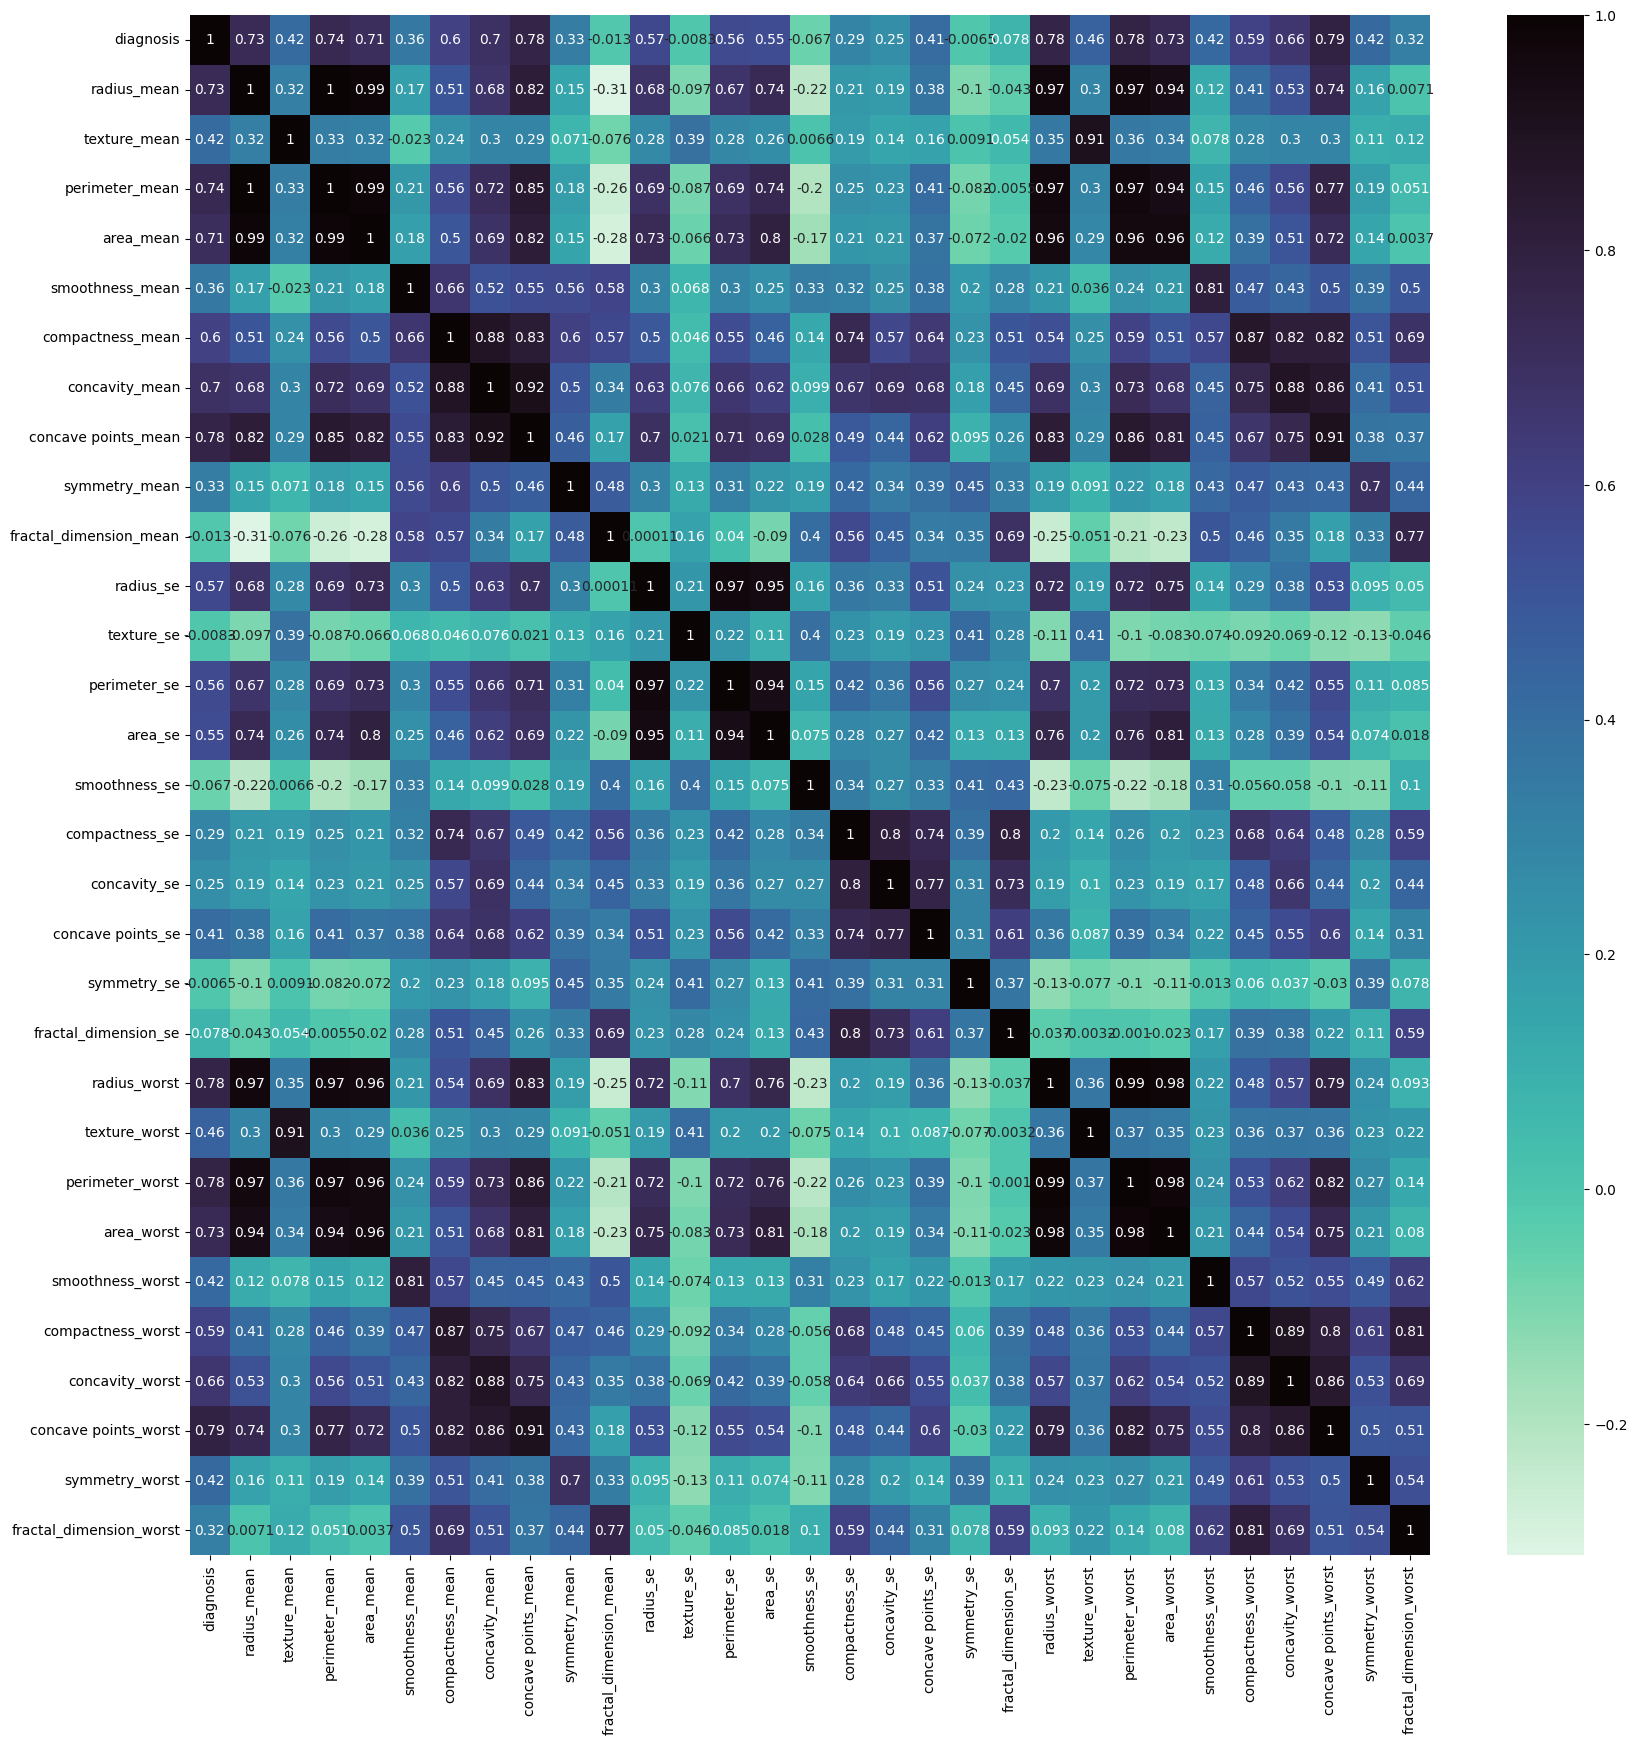

In [8]:
plt.figure(figsize=(20,20))sns.heatmap(corr, cmap='mako_r',annot=True)plt.show()

In [ ]:
# Get the absolute value of the correlation
cor_target = abs(corr["diagnosis"])

# Select highly correlated features (threshold = 0.2)
relevant_features = cor_target[cor_target > 0.2]

# Collect the names of the features
names = [index for index, value in relevant_features.items()]

# Drop the target variable from the results
names.remove('diagnosis')

# Display features
print(names)

In [12]:
X = df[names].valuesy = df['diagnosis'].values

In [ ]:
def train_test_split(X, y, random_state=42, test_size=0.2):
    # Get number of samples
    n_samples = X.shape[0]
    
    # Set the seed for the random number generator
    np.random.seed(random_state)
    
    # Shuffle the indices
    shuffled_indices = np.random.permutation(np.arange(n_samples))
    
    # Determine the size of the test set
    test_size = int(test_size * n_samples)
    
    # Split the indices into train and test
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]
    
    # Split the data
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [ ]:
def standardize_data(X_train, X_test):
    # Calculate the mean and standard deviation using the training data
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    
    # Standardize the data
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std
    
    return X_train, X_test


X_train, X_test = standardize_data(X_train, X_test)

In [16]:
def sigmoid(z):
    # Compute the sigmoid function using the formula:
        1 / (1 + e^(-z)).    sigmoid_result = 1 / (1 + np.exp(-z))    # Return the computed sigmoid value.    return sigmoid_resul
        t

In [ ]:
z = np.linspace(-12, 12, 200)
fig = px.line(x=z, y=sigmoid(z), title='Logistic Function',
             template="plotly_dark")
fig.update_layout(
    title_font_color="#41BEE9",
    xaxis=dict(color="#41BEE9"),
    yaxis=dict(color="#41BEE9"))
fig.show()

In [ ]:
class LogisticRegression:

    def __init__(self, learning_rate=0.0001):
        np.random.seed(1)
        self.learning_rate = learning_rate

    def initialize_parameter(self):
        self.W = np.zeros(self.X.shape[1])
        self.b = 0.0

    def forward(self, X):
        Z = np.matmul(X, self.W) + self.b
        A = sigmoid(Z)
        return A

    def compute_cost(self, predictions):
        m = self.X.shape[0]  # number of training examples
        
        # compute the cost
        # adding small value epsilon to avoid log of 0
        cost = np.sum((-np.log(predictions + 1e-8) * self.y) +
                     (-np.log(1 - predictions + 1e-8)) * (1 - self.y))
        cost = cost / m
        return cost

    def compute_gradient(self, predictions):
        # get training shape
        m = self.X.shape[0]
        
        # compute gradients
        dW = np.matmul(self.X.T, (predictions - self.y)) / m
        db = np.sum(predictions - self.y) / m
        
        return dW, db

    def update_parameters(self, dW, db):
        self.W = self.W - self.learning_rate * dW
        self.b = self.b - self.learning_rate * db

    def fit(self, X, y, epochs=100):
        self.X = X
        self.y = y
        self.initialize_parameter()
        
        for epoch in range(epochs):
            # forward propagation
            predictions = self.forward(self.X)
            
            # compute cost
            cost = self.compute_cost(predictions)
            
            # compute gradients
            dW, db = self.compute_gradient(predictions)
            
            # update parameters
            self.update_parameters(dW, db)
            
            if epoch % 10 == 0:
                print(f"Cost after epoch {epoch}: {cost}")

    def predict(self, X):
        predictions = self.forward(X)
        return (predictions >= 0.5).astype(int)

In [19]:
lg = LogisticRegression()lg.fit(X_train, y_train,100000)

Output hidden; open in https://colab.research.google.com to view.

In [20]:
lg.save_model("model.pkl")

In [27]:
# data cleaning and manipulationimport pandas as pdimport numpy as np# data visualizationimport matplotlib.pyplot as pltimport seaborn as sns# machine learningfrom sklearn.preprocessing
 import StandardScalerimport sklearn.linear_model as skl_lmfrom sklearn
 import preprocessingfrom sklearn
 import neighborsfrom sklearn.metrics
 import confusion_matrix, classification_report, precision_scorefrom sklearn.model_selection
 import train_test_splitimport statsmodels.api as smimport statsmodels.formula.api as smf

In [24]:
#skleardf2 = pd.read_csv('sample_data/log/breast-cancer.csv')df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
# first, drop all "worst" columns
cols = ['radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
       'smoothness_worst', 'compactness_worst', 'concavity_worst',
       'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
df2 = df2.drop(cols, axis=1)

# then, drop all columns related to the "perimeter" and "area" attributes
cols = ['perimeter_mean', 'perimeter_se', 'area_mean', 'area_se']
df2 = df2.drop(cols, axis=1)

In [28]:
y = df2["diagnosis"] # our target variableX = df2.drop(["diagnosis"], axis=1) # our predictors

In [29]:
# Create a scaler objectscaler = StandardScaler()# Fit the scaler to the data and transform the dataX_scaled = scaler.fit_transform(X)# X_scaled is now a numpy array with normalized data

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create logistic regression model
lr = LogisticRegression()

# Train the model on the training data
lr.fit(X_train, y_train)

# Predict the target variable on the test data
y_pred = lr.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score# Evaluate the accuracy of the modelaccuracy = accuracy_score(y_test, y_pred)print(f'Accuracy:
    {accuracy:
        .2f}')

Accuracy: 0.96


In [34]:
from sklearn.metrics import classification_reportprint(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           B       0.97      0.96      0.97       108
           M       0.94      0.95      0.94        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171

